# HCR Nusantara — Hybrid Cost-Sensitive Ensemble Pipeline
**Paper:** A Hybrid Cost Sensitive Ensemble Approach for Indonesian Local Script Handwritten Recognition  
**Environment:** macOS M1 · conda `ai_core` · Chapter IV Experiment  

**Pipeline:**  
`Data Loading → EDA → Preprocessing → Feature Extraction (MobileNetV2 / EfficientNet-B0) → Class Weights → Optuna Tuning → XGBoost / LightGBM / CatBoost → Evaluation`

---
## 0. Setup & Configuration

In [19]:
# Install required packages if not present (run once)
import subprocess, sys

PACKAGES = [
    "torch", "torchvision",
    "scikit-learn",
    "xgboost",
    "lightgbm",
    "catboost",
    "optuna",
    "matplotlib", "seaborn",
    "pandas", "numpy", "Pillow", "tqdm", "joblib",
]

IMPORT_MAP = {
    "scikit-learn": "sklearn", "Pillow": "PIL",
    "opencv-python-headless": "cv2",
}

for pkg in PACKAGES:
    mod = IMPORT_MAP.get(pkg, pkg.replace("-", "_").split(".")[0])
    try:
        __import__(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages available.")

All packages available.


In [20]:
import os
import time
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"PyTorch  : {torch.__version__}")
print(f"MPS avail: {torch.backends.mps.is_available()}")

PyTorch  : 2.10.0
MPS avail: True


In [21]:
# ── Configuration ─────────────────────────────────────────────────────────────
BASE_DIR     = Path(".")
DATASET_ROOT = BASE_DIR / "datasetscript"
OUTPUT_DIR   = BASE_DIR / "models"
FEATURES_DIR = BASE_DIR / "features"
OUTPUT_DIR.mkdir(exist_ok=True)
FEATURES_DIR.mkdir(exist_ok=True)

IMG_SIZE      = 224
BATCH_SIZE    = 64
RANDOM_STATE  = 42
TEST_SIZE     = 0.20

# ── Tuning config (optimised for M1 CPU) ──────────────────────────────────────
OPTUNA_TRIALS        = 15    # TPE converges well at 15 trials
TUNE_SUBSAMPLE_RATIO = 0.10  # 10% of train ≈ 4,500 samples per trial
PCA_COMPONENTS       = 256   # reduce 1280-d → 256-d  (~5x faster trees)

DEVICE = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available()         else
    torch.device("cpu")
)
print(f"Device: {DEVICE}")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

SCRIPT_CONFIGS = {
    "Bali":    {"paths": ["Bali/letter"]},
    "Batak":   {"paths": ["Batak"]},
    "Jawa":    {"paths": ["Jawa/all_class"]},
    "Jawi":    {"paths": ["Jawi/letter"]},
    "Kawi":    {"paths": ["Kawi"]},
    "Lampung": {"paths": ["Lampung"]},
    "Lontara": {"paths": ["Lontara"]},
    "Pallawa": {"paths": ["Pallawa"]},
    "Sunda":   {"paths": ["Sunda/consonant", "Sunda/vowel"]},
}

VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
PALETTE    = sns.color_palette("tab10", n_colors=9)

print("Configuration ready.")

Device: mps
Configuration ready.


---
## 1. Data Loading & Exploratory Data Analysis

In [22]:
def load_dataset(dataset_root: Path, configs: dict) -> pd.DataFrame:
    records = []
    for script, cfg in configs.items():
        for rel_path in cfg["paths"]:
            script_dir = dataset_root / rel_path
            if not script_dir.exists():
                print(f"  WARNING: {script_dir} not found — skipping.")
                continue
            for class_dir in sorted(script_dir.iterdir()):
                if not class_dir.is_dir():
                    continue
                label = f"{script}_{class_dir.name}"
                for img_path in class_dir.iterdir():
                    if img_path.suffix.lower() in VALID_EXTS:
                        records.append({
                            "filepath": str(img_path),
                            "label":    label,
                            "script":   script,
                            "class":    class_dir.name,
                        })
    return pd.DataFrame(records)


print("Loading dataset...")
t0 = time.time()
df = load_dataset(DATASET_ROOT, SCRIPT_CONFIGS)
print(f"Loaded {len(df):,} images in {time.time()-t0:.1f}s")
print(f"Scripts : {df['script'].nunique()}")
print(f"Classes : {df['label'].nunique()}")
df.head()

Loading dataset...


Loaded 55,713 images in 0.6s
Scripts : 9
Classes : 228


,filepath,label,script,class
0,datasetscript/Bali/letter/ba/Ba_238.jpg,Bali_ba,Bali,ba
1,datasetscript/Bali/letter/ba/Ba_210.jpg,Bali_ba,Bali,ba
2,datasetscript/Bali/letter/ba/Ba_204.jpg,Bali_ba,Bali,ba
3,datasetscript/Bali/letter/ba/Ba_24.jpg,Bali_ba,Bali,ba
4,datasetscript/Bali/letter/ba/Ba_30.jpg,Bali_ba,Bali,ba


In [23]:
# Dataset composition table (mirrors Table I from the paper)
summary = (
    df.groupby("script")
    .agg(Classes=("label", "nunique"), Images=("filepath", "count"))
    .reset_index()
)
summary["Percentage"] = (summary["Images"] / summary["Images"].sum() * 100).round(2)
summary = summary.sort_values("Images", ascending=False).reset_index(drop=True)
total = pd.DataFrame([["Total", summary["Classes"].sum(), summary["Images"].sum(), 100.0]],
                      columns=summary.columns)
print(pd.concat([summary, total], ignore_index=True).to_string(index=False))
print(f"\nImbalance ratio (max/min class): "
      f"{df.groupby('label')['filepath'].count().max() / df.groupby('label')['filepath'].count().min():.1f}x")

 script  Classes  Images  Percentage
  Sunda       32   20224     36.3000
   Jawa       20    9995     17.9400
   Kawi       31    6246     11.2100
Lampung       20    4996      8.9700
   Bali       18    4493      8.0600
Pallawa       33    3960      7.1100
Lontara       23    2299      4.1300
  Batak       19    1900      3.4100
   Jawi       32    1600      2.8700
  Total      228   55713    100.0000

Imbalance ratio (max/min class): 14.5x


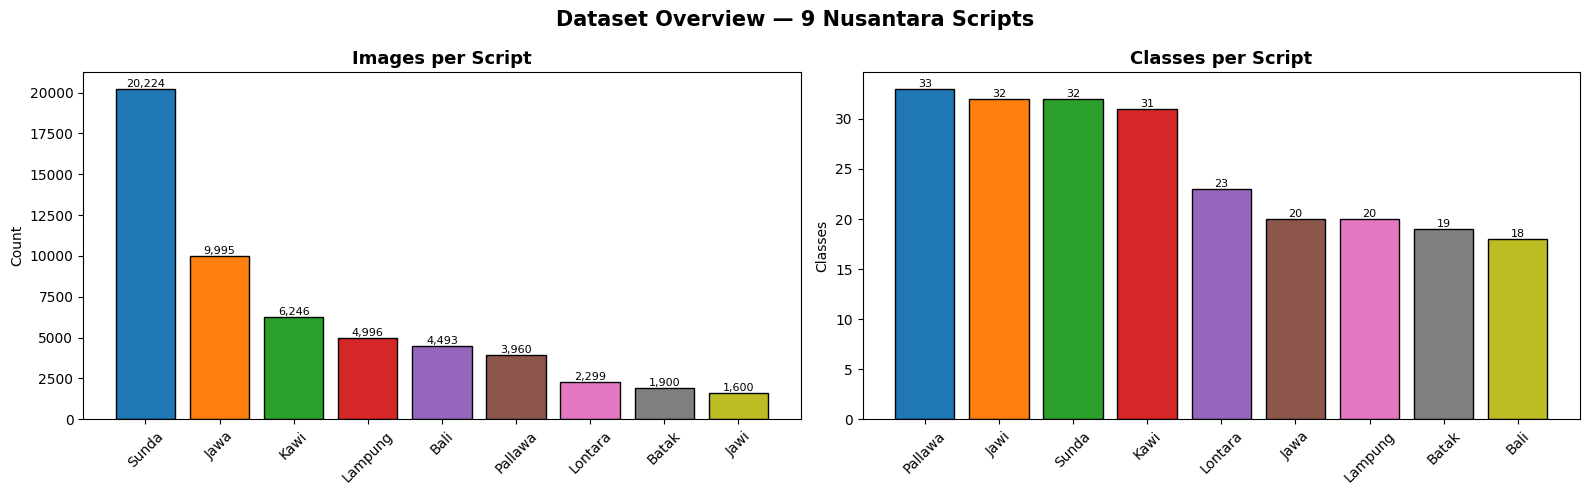

In [24]:
# EDA — script-level overview
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

script_img   = df.groupby("script")["filepath"].count().sort_values(ascending=False)
script_cls   = df.groupby("script")["label"].nunique().sort_values(ascending=False)

for ax, series, title, ylabel in [
    (axes[0], script_img, "Images per Script",  "Count"),
    (axes[1], script_cls, "Classes per Script", "Classes"),
]:
    bars = ax.bar(series.index, series.values, color=PALETTE, edgecolor="black")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=45)
    for bar in bars:
        ax.annotate(f"{int(bar.get_height()):,}",
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=8)

plt.suptitle("Dataset Overview — 9 Nusantara Scripts", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_script_overview.png", dpi=150, bbox_inches="tight")
plt.show()

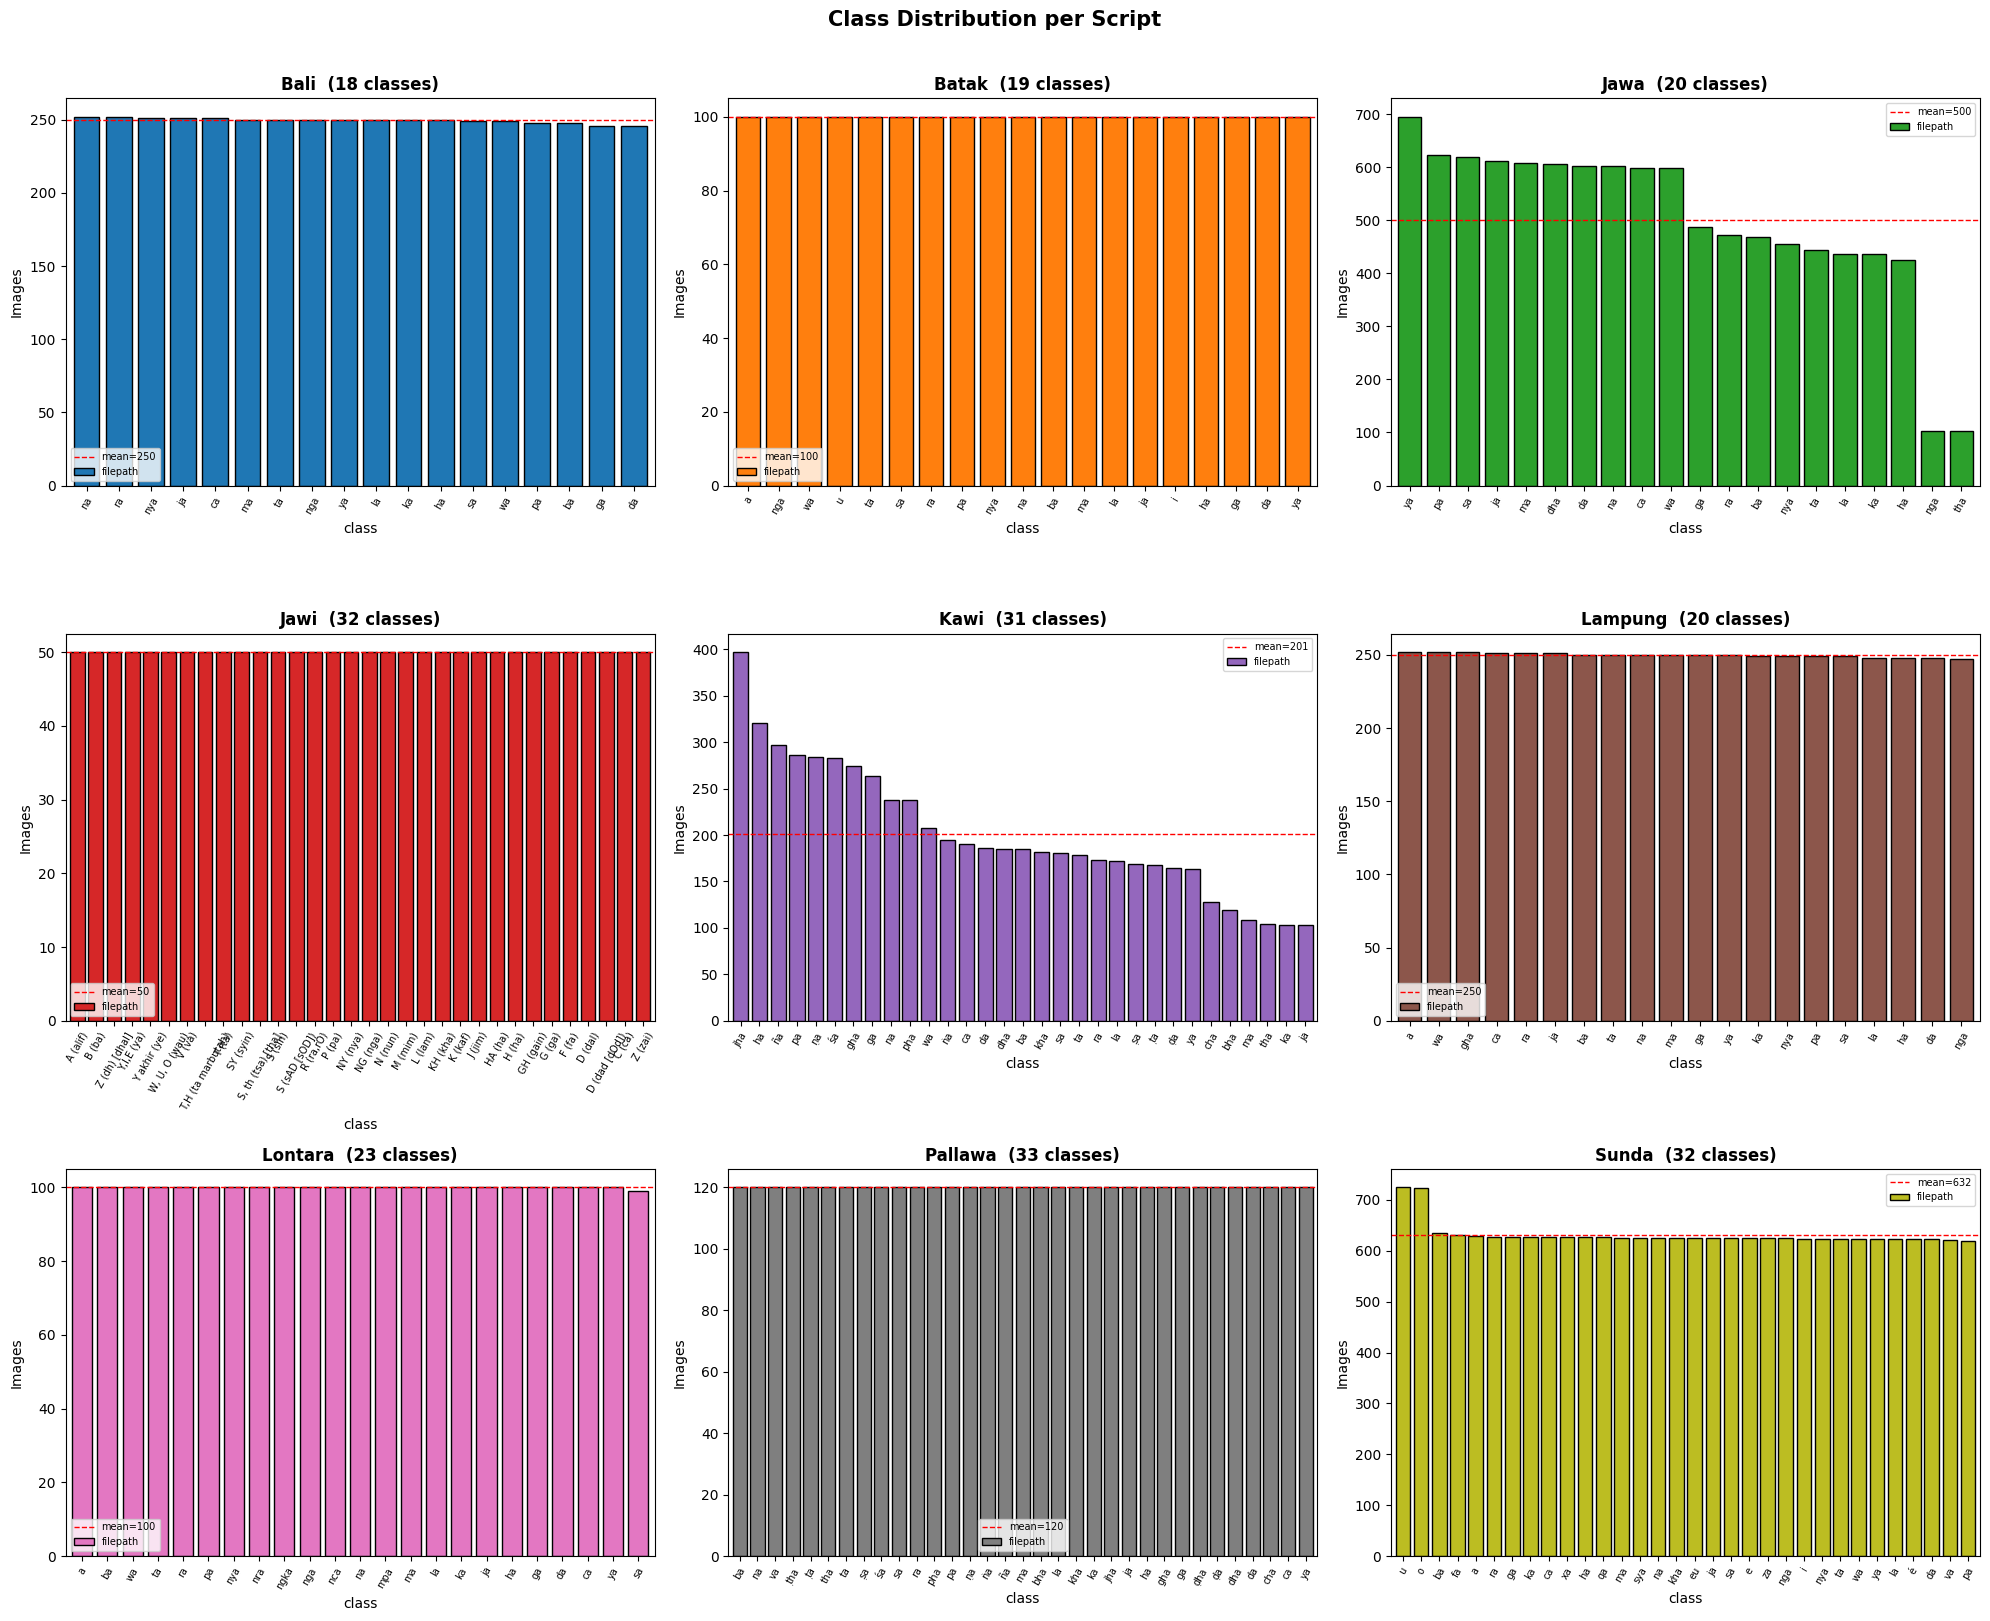

In [25]:
# EDA — within-script class distribution
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
for idx, (ax, script) in enumerate(zip(axes.flatten(), sorted(df["script"].unique()))):
    sub = df[df["script"] == script].groupby("class")["filepath"].count().sort_values(ascending=False)
    sub.plot(kind="bar", ax=ax, color=PALETTE[idx], edgecolor="black", width=0.8)
    ax.set_title(f"{script}  ({len(sub)} classes)", fontweight="bold")
    ax.set_ylabel("Images")
    ax.tick_params(axis="x", rotation=60, labelsize=7)
    ax.axhline(sub.mean(), color="red", linestyle="--", linewidth=1,
               label=f"mean={sub.mean():.0f}")
    ax.legend(fontsize=7)

plt.suptitle("Class Distribution per Script", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

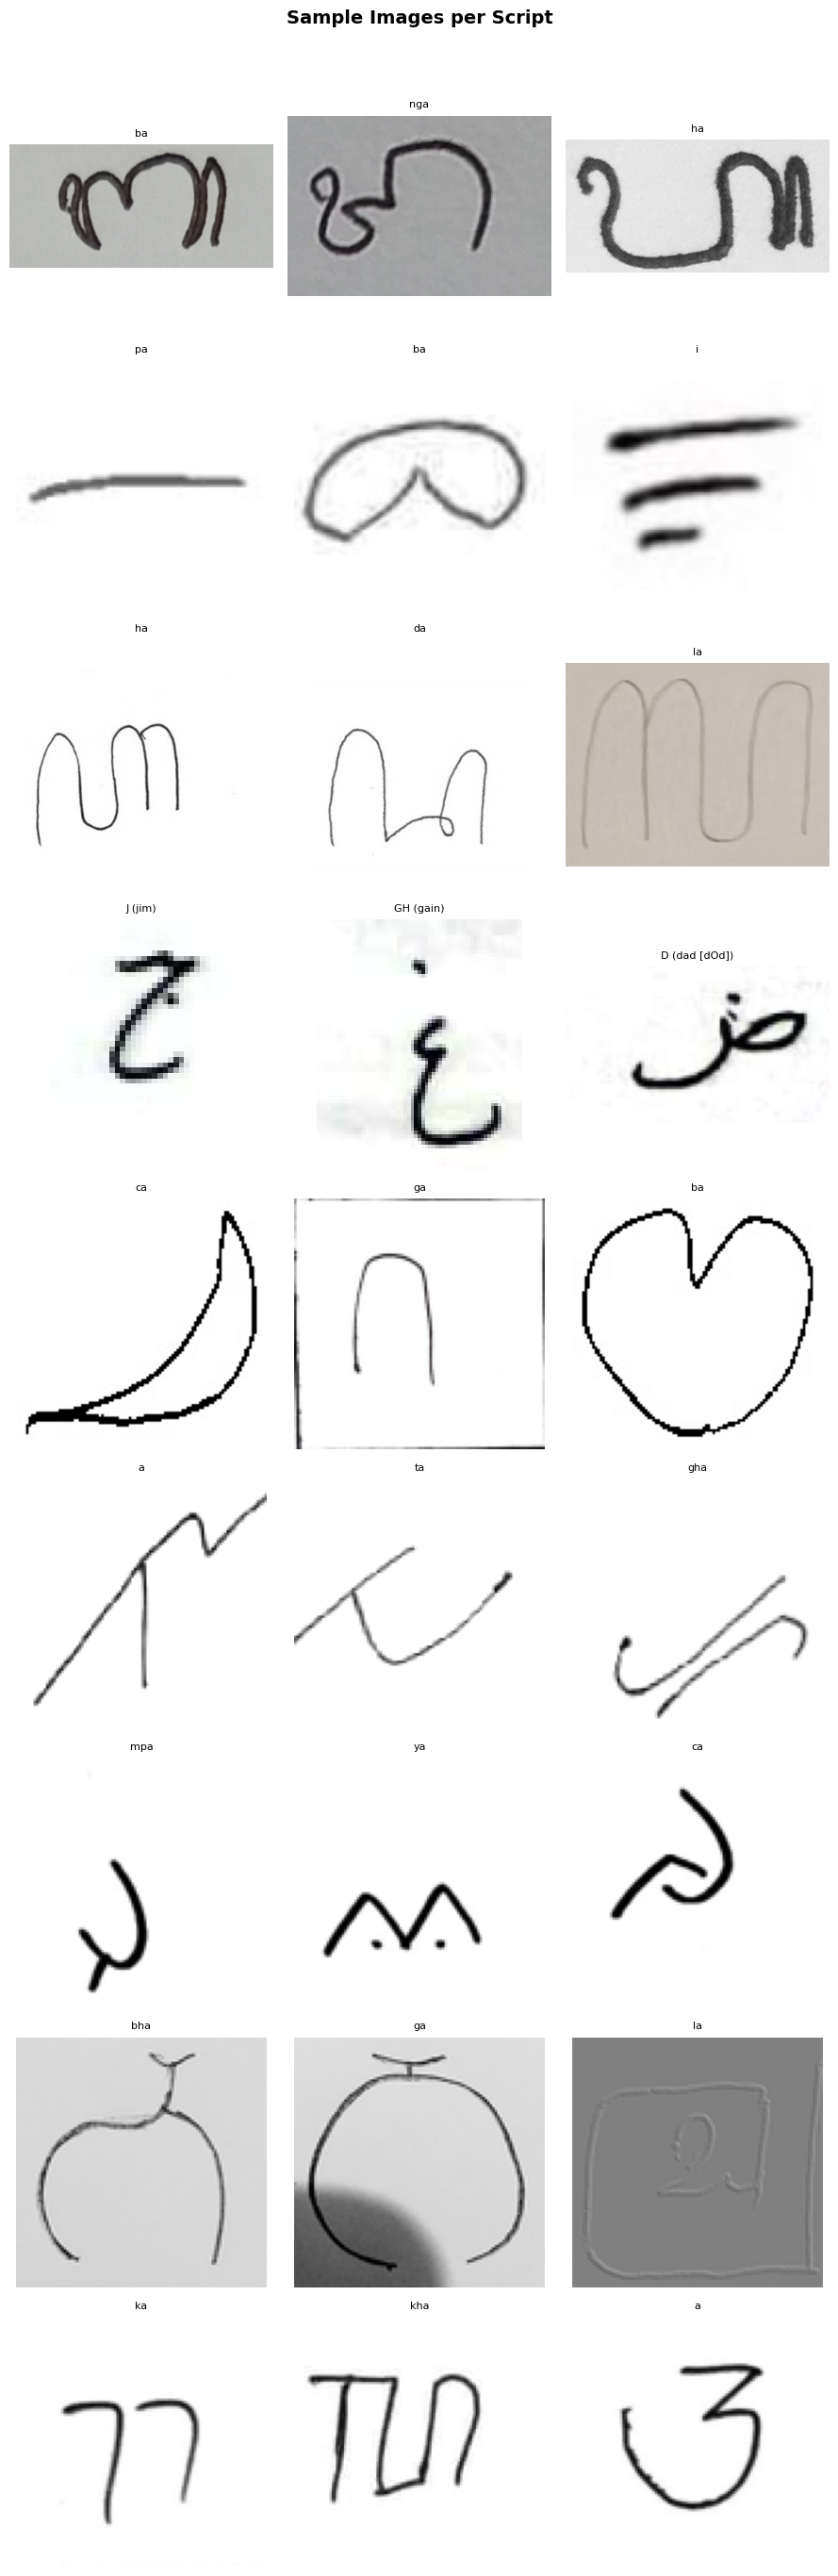

In [26]:
# EDA — sample image grid (3 samples × 9 scripts)
np.random.seed(RANDOM_STATE)
N_SAMPLES = 3
scripts   = sorted(df["script"].unique())

fig, axes = plt.subplots(len(scripts), N_SAMPLES, figsize=(N_SAMPLES * 3, len(scripts) * 3))
for row, script in enumerate(scripts):
    samples = df[df["script"] == script].sample(n=N_SAMPLES, random_state=RANDOM_STATE)
    for col, (_, record) in enumerate(samples.iterrows()):
        img = Image.open(record["filepath"]).convert("RGB")
        axes[row][col].imshow(img)
        axes[row][col].set_title(record["class"], fontsize=8)
        axes[row][col].axis("off")
    axes[row][0].set_ylabel(script, fontsize=11, fontweight="bold", rotation=90, labelpad=10)

plt.suptitle("Sample Images per Script", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Preprocessing & Data Splitting

In [27]:
# Label encoding
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])

CLASS_NAMES = le.classes_
N_CLASSES   = len(CLASS_NAMES)
np.save(OUTPUT_DIR / "class_names.npy", CLASS_NAMES)
joblib.dump(le, OUTPUT_DIR / "label_encoder.pkl")

print(f"Total classes : {N_CLASSES}")
print(f"Sample labels : {CLASS_NAMES[:5]} ... {CLASS_NAMES[-5:]}")

Total classes : 228
Sample labels : ['Bali_ba' 'Bali_ca' 'Bali_da' 'Bali_ga' 'Bali_ha'] ... ['Sunda_va' 'Sunda_wa' 'Sunda_xa' 'Sunda_ya' 'Sunda_za']


In [28]:
# Stratified 80/20 split
X_all = df["filepath"].values
y_all = df["label_enc"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all
)

np.save(FEATURES_DIR / "labels_train.npy", y_train)
np.save(FEATURES_DIR / "labels_test.npy",  y_test)

print(f"Train : {len(X_train):,}  ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test  : {len(X_test):,}   ({len(X_test)/len(df)*100:.1f}%)")

Train : 44,570  (80.0%)
Test  : 11,143   (20.0%)


In [29]:
# Preprocessing utilities
def binarize_pil(gray_img: Image.Image) -> Image.Image:
    """Mean-based binarization after Gaussian blur (fast, script-agnostic)."""
    blurred = np.array(gray_img.filter(ImageFilter.GaussianBlur(radius=1)))
    thresh  = blurred.mean()
    binary  = np.where(np.array(gray_img) < thresh, 0, 255).astype(np.uint8)
    return Image.fromarray(binary, mode="L")


def to_rgb_3ch(gray_img: Image.Image) -> Image.Image:
    """Replicate grayscale channel 3x to satisfy CNN RGB input."""
    return Image.merge("RGB", [gray_img, gray_img, gray_img])


BASE_TRANSFORM = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

AUGMENT_TRANSFORM = T.Compose([
    T.RandomHorizontalFlip(p=0.3),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.1),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Preprocessing transforms ready.")

Preprocessing transforms ready.


In [30]:
class NusantaraDataset(Dataset):
    def __init__(self, filepaths, labels, augment=False):
        self.filepaths = filepaths
        self.labels    = labels
        self.augment   = augment

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx])
        # Normalise mode
        if img.mode == "RGBA":
            bg = Image.new("RGB", img.size, (255, 255, 255))
            bg.paste(img, mask=img.split()[3])
            img = bg
        elif img.mode == "P":
            img = img.convert("RGBA").convert("RGB")
        else:
            img = img.convert("RGB")

        gray   = img.convert("L")
        binary = binarize_pil(gray)
        rgb    = to_rgb_3ch(binary)

        tensor = (AUGMENT_TRANSFORM if self.augment else BASE_TRANSFORM)(rgb)
        return tensor, int(self.labels[idx])


# Sanity check
img_t, lbl = NusantaraDataset(X_train[:4], y_train[:4])[0]
print(f"Tensor shape : {img_t.shape}")
print(f"Label        : {lbl}  →  {CLASS_NAMES[lbl]}")

Tensor shape : torch.Size([3, 224, 224])
Label        : 113  →  Kawi_śa


---
## 3. Feature Extraction — Frozen CNN Backbones

In [31]:
def build_extractor(backbone_name: str) -> nn.Module:
    """Frozen pretrained CNN with classification head removed."""
    if backbone_name == "mobilenet_v2":
        m = tv_models.mobilenet_v2(weights=tv_models.MobileNet_V2_Weights.IMAGENET1K_V1)
        m.classifier = nn.Identity()        # 1280-d output
    elif backbone_name == "efficientnet_b0":
        m = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        m.classifier = nn.Identity()        # 1280-d output
    else:
        raise ValueError(backbone_name)

    for p in m.parameters():
        p.requires_grad = False
    return m.eval().to(DEVICE)


@torch.no_grad()
def extract_features(extractor, filepaths, labels, desc=""):
    ds     = NusantaraDataset(filepaths, labels, augment=False)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=False)
    feats, lbls = [], []
    for imgs, batch_lbls in tqdm(loader, desc=desc, unit="batch"):
        f = extractor(imgs.to(DEVICE))
        feats.append(f.cpu().numpy())
        lbls.extend(batch_lbls.numpy().tolist())
    return np.vstack(feats), np.array(lbls)


print("Feature extraction utilities ready.")

Feature extraction utilities ready.


In [32]:
BACKBONES  = ["mobilenet_v2", "efficientnet_b0"]
FEATURES   = {}   # {backbone: {"train": (X, y), "test": (X, y)}}

for bb in BACKBONES:
    tr_path = FEATURES_DIR / f"features_train_{bb}.npy"
    te_path = FEATURES_DIR / f"features_test_{bb}.npy"

    if tr_path.exists() and te_path.exists():
        print(f"[{bb}] Loading cached features...")
        X_tr = np.load(tr_path)
        X_te = np.load(te_path)
        y_tr = np.load(FEATURES_DIR / "labels_train.npy")
        y_te = np.load(FEATURES_DIR / "labels_test.npy")
    else:
        print(f"\n[{bb}] Extracting features...")
        extractor = build_extractor(bb)
        t0 = time.time()
        X_tr, y_tr = extract_features(extractor, X_train, y_train, f"{bb} | train")
        X_te, y_te = extract_features(extractor, X_test,  y_test,  f"{bb} | test")
        print(f"  Time: {time.time()-t0:.1f}s")
        np.save(tr_path, X_tr)
        np.save(te_path, X_te)
        del extractor
        if DEVICE.type == "mps":
            torch.mps.empty_cache()

    FEATURES[bb] = {"train": (X_tr, y_tr), "test": (X_te, y_te)}
    print(f"  [{bb}] train {X_tr.shape}  test {X_te.shape}")

print("\nFeature extraction complete.")


[mobilenet_v2] Extracting features...


mobilenet_v2 | train: 100%|██████████| 697/697 [10:54<00:00,  1.06batch/s]
mobilenet_v2 | test: 100%|██████████| 175/175 [02:45<00:00,  1.06batch/s]


  Time: 825.3s
  [mobilenet_v2] train (44570, 1280)  test (11143, 1280)

[efficientnet_b0] Extracting features...


efficientnet_b0 | train: 100%|██████████| 697/697 [16:23<00:00,  1.41s/batch]
efficientnet_b0 | test: 100%|██████████| 175/175 [03:06<00:00,  1.07s/batch]


  Time: 1175.8s
  [efficientnet_b0] train (44570, 1280)  test (11143, 1280)

Feature extraction complete.


---
## 3.5 Dimensionality Reduction — PCA

Compress CNN features **1280-d → 256-d** before feeding tree models.  
Tree models (XGBoost, LightGBM, CatBoost) do not benefit from all 1280 dimensions — PCA retains ~95%+ variance while giving **~5× speedup** on M1 CPU.

In [33]:
from sklearn.decomposition import PCA

PCA_MODELS = {}   # {backbone: fitted PCA model}

for bb in BACKBONES:
    pca_path    = FEATURES_DIR / f"pca_{bb}.pkl"
    tr_pca_path = FEATURES_DIR / f"features_train_{bb}_pca{PCA_COMPONENTS}.npy"
    te_pca_path = FEATURES_DIR / f"features_test_{bb}_pca{PCA_COMPONENTS}.npy"

    X_tr, y_tr = FEATURES[bb]["train"]
    X_te, y_te = FEATURES[bb]["test"]

    if pca_path.exists() and tr_pca_path.exists():
        print(f"[{bb}] Loading cached PCA features...")
        pca        = joblib.load(pca_path)
        X_tr_pca   = np.load(tr_pca_path)
        X_te_pca   = np.load(te_pca_path)
    else:
        print(f"[{bb}] Fitting PCA {X_tr.shape[1]}-d → {PCA_COMPONENTS}-d ...")
        pca      = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_STATE)
        X_tr_pca = pca.fit_transform(X_tr)
        X_te_pca = pca.transform(X_te)
        joblib.dump(pca, pca_path)
        np.save(tr_pca_path, X_tr_pca)
        np.save(te_pca_path, X_te_pca)

    PCA_MODELS[bb] = pca
    FEATURES[bb]["train"] = (X_tr_pca, y_tr)
    FEATURES[bb]["test"]  = (X_te_pca, y_te)

    var_retained = pca.explained_variance_ratio_.sum() * 100
    print(f"  {X_tr.shape[1]}-d → {PCA_COMPONENTS}-d  |  variance retained: {var_retained:.1f}%  |  "
          f"train {X_tr_pca.shape}  test {X_te_pca.shape}")

print("\nPCA compression complete.")

[mobilenet_v2] Loading cached PCA features...
  1280-d → 256-d  |  variance retained: 95.9%  |  train (44570, 256)  test (11143, 256)
[efficientnet_b0] Loading cached PCA features...
  1280-d → 256-d  |  variance retained: 94.1%  |  train (44570, 256)  test (11143, 256)

PCA compression complete.


---
## 4. Class Weight Computation (Cost-Sensitive Learning)

In [34]:
y_tr_ref = FEATURES[BACKBONES[0]]["train"][1]
unique_cls = np.unique(y_tr_ref)

cw_arr  = compute_class_weight("balanced", classes=unique_cls, y=y_tr_ref)
cw_dict = dict(zip(unique_cls.tolist(), cw_arr.tolist()))

print(f"Classes with weights : {len(cw_arr)}")
print(f"Min weight (majority): {cw_arr.min():.4f}")
print(f"Max weight (minority): {cw_arr.max():.4f}")
print(f"Mean weight          : {cw_arr.mean():.4f}")

Classes with weights : 228
Min weight (majority): 0.3370
Max weight (minority): 4.8871
Mean weight          : 1.8914


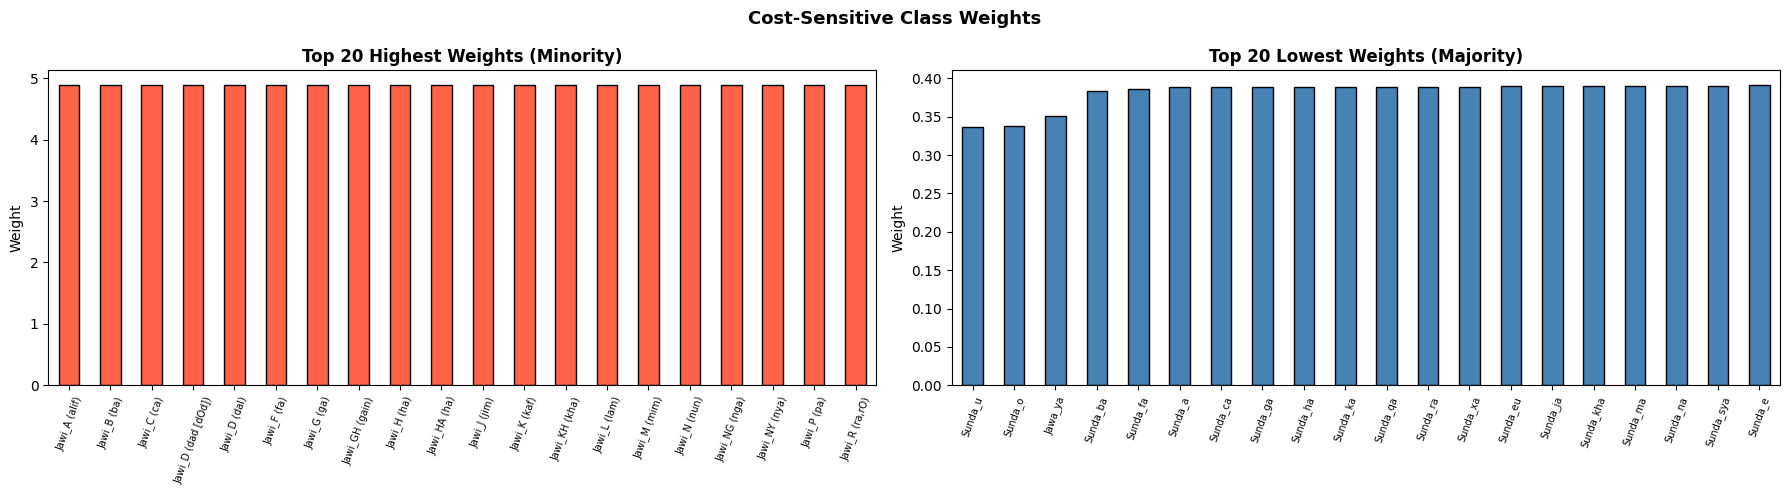

In [35]:
# Visualise top-20 highest / lowest class weights
ws = pd.Series(cw_arr, index=[CLASS_NAMES[i] for i in unique_cls])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
ws.nlargest(20).plot(kind="bar",  ax=axes[0], color="tomato",    edgecolor="black")
ws.nsmallest(20).plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="black")
axes[0].set_title("Top 20 Highest Weights (Minority)", fontweight="bold")
axes[1].set_title("Top 20 Lowest Weights (Majority)",  fontweight="bold")
for ax in axes:
    ax.set_ylabel("Weight")
    ax.tick_params(axis="x", rotation=70, labelsize=7)
plt.suptitle("Cost-Sensitive Class Weights", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_weights.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Hyperparameter Tuning with Optuna

In [36]:
# ── Helper: prepare tuning data ───────────────────────────────────────────────
def get_tune_splits(X, y, sw=None):
    """
    Subsample TUNE_SUBSAMPLE_RATIO of data, then split into train/val.
    Called once per backbone — all 3 models share the same splits.
    """
    _, sub_idx = train_test_split(
        np.arange(len(y)), test_size=TUNE_SUBSAMPLE_RATIO,
        stratify=y, random_state=RANDOM_STATE
    )
    Xs, ys = X[sub_idx], y[sub_idx]
    sws    = sw[sub_idx] if sw is not None else None

    tr, va = next(
        StratifiedShuffleSplit(1, test_size=0.15, random_state=RANDOM_STATE).split(Xs, ys)
    )
    return Xs[tr], ys[tr], Xs[va], ys[va], (sws[tr] if sws is not None else None)


# ── Objective functions (one per model) ───────────────────────────────────────
def xgb_objective(trial, X_tr, y_tr, X_va, y_va, sw_tr):
    model = xgb.XGBClassifier(
        n_estimators          = trial.suggest_int("n_estimators", 50, 200, step=50),
        max_depth             = trial.suggest_int("max_depth", 3, 7),
        learning_rate         = trial.suggest_float("learning_rate", 0.05, 0.3, log=True),
        subsample             = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree      = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha             = trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda            = trial.suggest_float("reg_lambda", 1e-3, 1.0, log=True),
        eval_metric           = "mlogloss",
        use_label_encoder     = False,
        tree_method           = "hist",
        early_stopping_rounds = 15,
        random_state          = RANDOM_STATE,
        n_jobs=-1, verbosity=0,
    )
    model.fit(X_tr, y_tr, sample_weight=sw_tr,
              eval_set=[(X_va, y_va)], verbose=False)
    return f1_score(y_va, model.predict(X_va), average="macro", zero_division=0)


def lgbm_objective(trial, X_tr, y_tr, X_va, y_va):
    model = lgb.LGBMClassifier(
        n_estimators     = trial.suggest_int("n_estimators", 50, 200, step=50),
        num_leaves       = trial.suggest_int("num_leaves", 20, 80),
        learning_rate    = trial.suggest_float("learning_rate", 0.05, 0.3, log=True),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-3, 1.0, log=True),
        objective        = "multiclass",
        metric           = "multi_logloss",
        class_weight     = cw_dict,
        random_state     = RANDOM_STATE,
        n_jobs=-1, verbose=-1,
    )
    model.fit(X_tr, y_tr,
              eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(15, verbose=False), lgb.log_evaluation(-1)])
    return f1_score(y_va, model.predict(X_va), average="macro", zero_division=0)


def cat_objective(trial, X_tr, y_tr, X_va, y_va):
    model = CatBoostClassifier(
        iterations    = trial.suggest_int("iterations", 50, 200, step=50),
        depth         = trial.suggest_int("depth", 3, 7),
        learning_rate = trial.suggest_float("learning_rate", 0.05, 0.3, log=True),
        l2_leaf_reg   = trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        loss_function = "MultiClass",
        eval_metric   = "MultiClass",
        class_weights = list(cw_arr),
        random_seed   = RANDOM_STATE,
        verbose=False, allow_writing_files=False,
    )
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=15)
    return f1_score(y_va, model.predict(X_va).flatten(), average="macro", zero_division=0)


n_tune = int(len(y_train) * TUNE_SUBSAMPLE_RATIO)
print(f"Objectives ready — tuning on ~{n_tune:,} samples × {PCA_COMPONENTS}-d  |  {OPTUNA_TRIALS} trials/model")

Objectives ready — tuning on ~4,457 samples × 256-d  |  15 trials/model


In [ ]:
BEST_PARAMS = {}   # {(backbone, model_name): best hyperparams}

for bb in BACKBONES:
    X_full, y_full = FEATURES[bb]["train"]
    sw_full = np.array([cw_dict[c] for c in y_full])

    # Compute subsample splits once — shared across all 3 models for this backbone
    X_tr_t, y_tr_t, X_va_t, y_va_t, sw_tr_t = get_tune_splits(X_full, y_full, sw_full)

    print(f"\n{'='*55}")
    print(f"  {bb}  |  tune: {len(y_tr_t):,} train  {len(y_va_t):,} val  ({PCA_COMPONENTS}-d)")
    print(f"{'='*55}")

    configs = [
        ("xgb",  lambda t: xgb_objective(t, X_tr_t, y_tr_t, X_va_t, y_va_t, sw_tr_t)),
        ("lgbm", lambda t: lgbm_objective(t, X_tr_t, y_tr_t, X_va_t, y_va_t)),
        ("cat",  lambda t: cat_objective(t,  X_tr_t, y_tr_t, X_va_t, y_va_t)),
    ]

    for name, obj_fn in configs:
        print(f"  Tuning {name.upper()} ({OPTUNA_TRIALS} trials)...")
        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
        )
        study.optimize(obj_fn, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
        BEST_PARAMS[(bb, name)] = study.best_params
        print(f"  → best val Macro-F1: {study.best_value:.4f}")

print("\nHyperparameter tuning complete.")


  mobilenet_v2  |  tune: 3,788 train  669 val  (256-d)
  Tuning XGB (15 trials)...


Best trial: 4. Best value: 0.564211: 100%|██████████| 15/15 [27:18<00:00, 109.22s/it]


  → best val Macro-F1: 0.5642
  Tuning LGBM (15 trials)...


Best trial: 9. Best value: 0.474272: 100%|██████████| 15/15 [20:51<00:00, 83.41s/it] 


  → best val Macro-F1: 0.4743
  Tuning CAT (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
# Best hyperparameter summary
for (bb, mk), params in BEST_PARAMS.items():
    print(f"\n[{bb}] [{mk.upper()}]")
    for k, v in params.items():
        print(f"  {k:<22} = {v}")

---
## 6. Model Training (Cost-Sensitive Ensemble)

In [ ]:
MODEL_DISPLAY      = {"xgb": "XGBoost", "lgbm": "LightGBM", "cat": "CatBoost"}
TRAINED            = {}
FINAL_N_ESTIMATORS = 400   # scale up from tuning range (50-200) for final model

for bb in BACKBONES:
    X_tr, y_tr = FEATURES[bb]["train"]   # already PCA-reduced
    sw = np.array([cw_dict[c] for c in y_tr])

    print(f"\nTraining [{bb}]  ({len(X_tr):,} samples × {X_tr.shape[1]}-d) ...")

    # XGBoost — sample_weight for cost-sensitive learning
    xgb_params = {
        **BEST_PARAMS[(bb, "xgb")],
        "n_estimators": FINAL_N_ESTIMATORS,
        "eval_metric": "mlogloss", "use_label_encoder": False,
        "tree_method": "hist", "random_state": RANDOM_STATE,
        "n_jobs": -1, "verbosity": 0,
    }
    xgb_params.pop("early_stopping_rounds", None)
    t0 = time.time()
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(X_tr, y_tr, sample_weight=sw, verbose=False)
    print(f"  XGBoost  {time.time()-t0:.0f}s")
    joblib.dump(xgb_model, OUTPUT_DIR / f"{bb}_xgb.pkl")
    TRAINED[(bb, "xgb")] = xgb_model

    # LightGBM — class_weight dict for cost-sensitive learning
    lgbm_params = {
        **BEST_PARAMS[(bb, "lgbm")],
        "n_estimators": FINAL_N_ESTIMATORS,
        "objective": "multiclass", "metric": "multi_logloss",
        "class_weight": cw_dict, "random_state": RANDOM_STATE,
        "n_jobs": -1, "verbose": -1,
    }
    t0 = time.time()
    lgbm_model = lgb.LGBMClassifier(**lgbm_params)
    lgbm_model.fit(X_tr, y_tr)
    print(f"  LightGBM {time.time()-t0:.0f}s")
    joblib.dump(lgbm_model, OUTPUT_DIR / f"{bb}_lgbm.pkl")
    TRAINED[(bb, "lgbm")] = lgbm_model

    # CatBoost — class_weights list for cost-sensitive learning
    bp = BEST_PARAMS[(bb, "cat")]
    cat_model = CatBoostClassifier(
        iterations    = FINAL_N_ESTIMATORS,
        depth         = bp.get("depth", 6),
        learning_rate = bp.get("learning_rate", 0.1),
        l2_leaf_reg   = bp.get("l2_leaf_reg", 3.0),
        loss_function = "MultiClass",
        eval_metric   = "MultiClass",
        class_weights = list(cw_arr),
        random_seed   = RANDOM_STATE,
        verbose=False, allow_writing_files=False,
    )
    t0 = time.time()
    cat_model.fit(X_tr, y_tr)
    print(f"  CatBoost {time.time()-t0:.0f}s")
    cat_model.save_model(str(OUTPUT_DIR / f"{bb}_catboost.cbm"))
    TRAINED[(bb, "cat")] = cat_model

print("\nAll 6 models trained and saved.")

---
## 7. Model Evaluation

In [ ]:
# Evaluate all 6 model variants
RESULTS     = []
PREDICTIONS = {}

for bb in BACKBONES:
    X_te_b, y_te_b = FEATURES[bb]["test"]

    for mk in ["xgb", "lgbm", "cat"]:
        model  = TRAINED[(bb, mk)]
        y_pred = np.array(model.predict(X_te_b)).flatten().astype(int)
        PREDICTIONS[(bb, mk)] = y_pred

        acc  = accuracy_score(y_te_b, y_pred)
        mp   = precision_score(y_te_b, y_pred, average="macro", zero_division=0)
        mr   = recall_score(y_te_b, y_pred, average="macro", zero_division=0)
        mf1  = f1_score(y_te_b, y_pred, average="macro", zero_division=0)

        RESULTS.append({"Backbone": bb, "Model": MODEL_DISPLAY[mk],
                         "Accuracy": round(acc, 4), "Macro Precision": round(mp, 4),
                         "Macro Recall": round(mr, 4), "Macro F1": round(mf1, 4)})

        print(f"[{bb}] {MODEL_DISPLAY[mk]:<10}  "
              f"Macro-F1={mf1:.4f}  Acc={acc:.4f}  P={mp:.4f}  R={mr:.4f}")

print("\nEvaluation complete.")

In [ ]:
# Summary comparison table
results_df = (
    pd.DataFrame(RESULTS)
    .sort_values("Macro F1", ascending=False)
    .reset_index(drop=True)
)
results_df.index += 1
print("── Model Comparison (sorted by Macro F1) ──")
display(results_df)

In [ ]:
# Bar chart comparison
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
tick_labels = [
    f"{r['Backbone'].replace('_',' ')}\n{r['Model']}"
    for _, r in results_df.iterrows()
]
colors = ["#2196F3" if "mobilenet" in results_df.iloc[i]["Backbone"] else "#FF5722"
          for i in range(len(results_df))]

for ax, metric in zip(axes, ["Macro F1", "Accuracy"]):
    vals = results_df[metric].values
    bars = ax.bar(tick_labels, vals, color=colors, edgecolor="black", alpha=0.85)
    ax.set_title(f"{metric} Comparison", fontweight="bold", fontsize=13)
    ax.set_ylabel(metric)
    ax.set_ylim(max(0, vals.min() - 0.05), min(1.0, vals.max() + 0.06))
    ax.tick_params(axis="x", labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{v:.4f}", ha="center", fontsize=8)

legend_elems = [Patch(facecolor="#2196F3", label="MobileNetV2"),
                Patch(facecolor="#FF5722", label="EfficientNet-B0")]
axes[0].legend(handles=legend_elems, loc="lower right")

plt.suptitle("Hybrid CNN-Ensemble — Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Best model — full classification report
best_row  = results_df.iloc[0]
best_bb   = best_row["Backbone"]
best_mk   = {v: k for k, v in MODEL_DISPLAY.items()}[best_row["Model"]]

_, y_te_best  = FEATURES[best_bb]["test"]
y_pred_best   = PREDICTIONS[(best_bb, best_mk)]

report = classification_report(y_te_best, y_pred_best,
                                target_names=CLASS_NAMES, digits=4, zero_division=0)

print(f"Best: [{best_bb}] + [{best_row['Model']}]  Macro-F1={best_row['Macro F1']}\n")
print(report)

with open(OUTPUT_DIR / "best_model_report.txt", "w") as f:
    f.write(f"{best_bb} + {best_row['Model']}  Macro-F1={best_row['Macro F1']}\n\n{report}")

print("Report saved.")

In [ ]:
# Per-script accuracy heatmap (9×9)
label_to_script = {i: CLASS_NAMES[i].split("_")[0] for i in range(N_CLASSES)}
scripts_ord     = sorted(df["script"].unique())
script_idx      = {s: i for i, s in enumerate(scripts_ord)}


def script_confusion(y_true, y_pred):
    n  = len(scripts_ord)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        ts = label_to_script.get(int(t))
        ps = label_to_script.get(int(p))
        if ts and ps:
            cm[script_idx[ts], script_idx[ps]] += 1
    rs = cm.sum(axis=1, keepdims=True)
    return cm / np.where(rs == 0, 1, rs)


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, bb in zip(axes, BACKBONES):
    _, y_te_b = FEATURES[bb]["test"]
    top_m = results_df[results_df["Backbone"] == bb].iloc[0]["Model"]
    top_k = {v: k for k, v in MODEL_DISPLAY.items()}[top_m]
    sm = script_confusion(y_te_b, PREDICTIONS[(bb, top_k)])

    sns.heatmap(sm, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5,
                xticklabels=scripts_ord, yticklabels=scripts_ord,
                vmin=0, vmax=1, ax=ax, annot_kws={"size": 8})
    ax.set_title(f"{bb.replace('_',' ')} + {top_m}", fontweight="bold")
    ax.set_xlabel("Predicted Script")
    ax.set_ylabel("True Script")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("Per-Script Accuracy Heatmap (Best Model per Backbone)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_script_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Full normalised confusion matrix — best model
cm_full = confusion_matrix(y_te_best, y_pred_best)
cm_norm = cm_full.astype(float) / np.where(cm_full.sum(1, keepdims=True) == 0, 1,
                                             cm_full.sum(1, keepdims=True))

fig, ax = plt.subplots(figsize=(30, 28))
im = ax.imshow(cm_norm, cmap="Blues", aspect="auto", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)

for i in range(N_CLASSES):  # annotate diagonal only for readability
    ax.text(i, i, f"{cm_norm[i,i]:.2f}", ha="center", va="center",
            fontsize=4, color=("white" if cm_norm[i, i] > 0.6 else "black"))

step = max(1, N_CLASSES // 30)
ticks = list(range(0, N_CLASSES, step))
ax.set_xticks(ticks); ax.set_xticklabels([CLASS_NAMES[i] for i in ticks], rotation=90, fontsize=5)
ax.set_yticks(ticks); ax.set_yticklabels([CLASS_NAMES[i] for i in ticks], fontsize=5)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("True", fontsize=10)
ax.set_title(f"Normalised Confusion Matrix\n{best_bb.replace('_',' ')} + {best_row['Model']}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Macro F1 per script (best model)
rep_dict = classification_report(
    y_te_best, y_pred_best, target_names=CLASS_NAMES,
    output_dict=True, zero_division=0
)
script_f1 = {}
for label, vals in rep_dict.items():
    if "_" in label and isinstance(vals, dict):
        s = label.split("_")[0]
        script_f1.setdefault(s, []).append(vals["f1-score"])
script_f1_mean = pd.Series({s: np.mean(v) for s, v in script_f1.items()}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(script_f1_mean.index, script_f1_mean.values,
               color=PALETTE, edgecolor="black", alpha=0.9)
ax.axhline(script_f1_mean.mean(), color="red", linestyle="--",
           label=f"Mean = {script_f1_mean.mean():.4f}")
ax.set_title(f"Macro F1 per Script — {best_bb.replace('_',' ')} + {best_row['Model']}",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.1)
ax.legend()
for bar, v in zip(bars, script_f1_mean.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "macro_f1_per_script.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Inference Demo

In [ ]:
@torch.no_grad()
def predict_image(image_path, extractor, pca, model, label_enc, top_k=5):
    """Predict script/class for a single handwritten character image."""
    img = Image.open(image_path)
    if img.mode == "RGBA":
        bg = Image.new("RGB", img.size, (255, 255, 255))
        bg.paste(img, mask=img.split()[3])
        img = bg
    elif img.mode == "P":
        img = img.convert("RGBA").convert("RGB")
    else:
        img = img.convert("RGB")

    binary = binarize_pil(img.convert("L"))
    tensor = BASE_TRANSFORM(to_rgb_3ch(binary)).unsqueeze(0).to(DEVICE)

    feat_1280 = extractor(tensor).cpu().numpy()     # (1, 1280)
    feat_256  = pca.transform(feat_1280)             # (1, 256)

    pred_enc   = int(np.array(model.predict(feat_256)).flatten()[0])
    pred_label = label_enc.inverse_transform([pred_enc])[0]

    top_k_out = None
    if hasattr(model, "predict_proba"):
        proba     = model.predict_proba(feat_256)[0]
        top_idx   = np.argsort(proba)[::-1][:top_k]
        top_k_out = [(label_enc.inverse_transform([i])[0], round(float(proba[i]), 4))
                     for i in top_idx]

    return {
        "predicted_label": pred_label,
        "script":    pred_label.split("_")[0],
        "character": "_".join(pred_label.split("_")[1:]),
        "top_k":     top_k_out,
    }

print("Inference function ready.")

In [ ]:
inf_extractor = build_extractor(best_bb)
inf_pca       = PCA_MODELS[best_bb]
inf_model     = TRAINED[(best_bb, best_mk)]

demo_scripts = ["Bali", "Kawi", "Lontara"]
demo_rows    = [df[df["script"] == s].sample(1, random_state=RANDOM_STATE + 7).iloc[0]
                for s in demo_scripts]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, row in zip(axes, demo_rows):
    result = predict_image(row["filepath"], inf_extractor, inf_pca, inf_model, le)
    ax.imshow(Image.open(row["filepath"]).convert("RGB"))
    ax.axis("off")
    color = "green" if row["label"] == result["predicted_label"] else "red"
    ax.set_title(f"GT:   {row['label']}\nPred: {result['predicted_label']}",
                 color=color, fontsize=9, fontweight="bold")

plt.suptitle("Inference Demo — Ground Truth vs Prediction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "inference_demo.png", dpi=150, bbox_inches="tight")
plt.show()

r = predict_image(demo_rows[0]["filepath"], inf_extractor, inf_pca, inf_model, le)
print(f"Top-5 predictions for '{demo_rows[0]['label']}':")
if r["top_k"]:
    for rank, (lbl, prob) in enumerate(r["top_k"], 1):
        print(f"  {rank}. {lbl:<30} {prob:.4f}")

---
## 9. Final Summary

In [ ]:
print("=" * 65)
print("  HCR NUSANTARA — EXPERIMENT SUMMARY")
print("=" * 65)
print(f"  Dataset        : 9 Indonesian local scripts")
print(f"  Total images   : {len(df):,}")
print(f"  Total classes  : {N_CLASSES}")
print(f"  Train / Test   : {len(X_train):,} / {len(X_test):,}  (stratified 80/20)")
print(f"  Backbones      : MobileNetV2, EfficientNet-B0 (frozen ImageNet)")
print(f"  Feature dim    : 1280-d per image")
print(f"  Class balance  : compute_class_weight('balanced')")
print(f"  HP tuning      : Optuna TPE — {OPTUNA_TRIALS} trials per model")
print()
print("  ── Results (by Macro F1) ──")
print(results_df.to_string(index=True))
print()
print(f"  Best model  : {best_bb} + {best_row['Model']}")
print(f"  Macro F1    : {best_row['Macro F1']}")
print(f"  Accuracy    : {best_row['Accuracy']}")
print()
print("  Saved artifacts:")
for fp in sorted(OUTPUT_DIR.iterdir()):
    print(f"    {fp.name}")
print("=" * 65)